## 실습 문제: 균등 분포 난수 생성 및 비교

**설명**: Python의 기본 `random` 모듈과 `NumPy` 라이브러리는 모두 [0, 1] 범위의 균등 분포 난수를 생성하는 기능을 제공합니다. 이 실습의 목표는 `random.uniform()` 함수와 `np.random.rand()` 함수를 각각 사용하여 난수를 생성하고, Matplotlib을 이용해 두 결과의 분포를 히스토그램으로 시각화하여 두 함수가 실제로 유사한 균등 분포를 따르는지 눈으로 확인하는 것입니다.

**요구사항**:
- `random.uniform(0, 1)`을 1000번 반복 호출하여 1000개의 난수가 담긴 리스트를 생성하세요.
- `np.random.rand(1000)`을 호출하여 1000개의 난수로 이루어진 NumPy 배열을 생성하세요.
- Matplotlib의 `subplot` 기능을 사용하여 두 개의 히스토그램을 나란히 그리고, 각 히스토그램에 어떤 함수로 생성된 데이터인지 명시하는 제목을 설정하세요.
- 두 히스토그램의 모양이 특정 구간에 치우치지 않고 전반적으로 평평하게 나타나는지 비교하여 확인하세요.

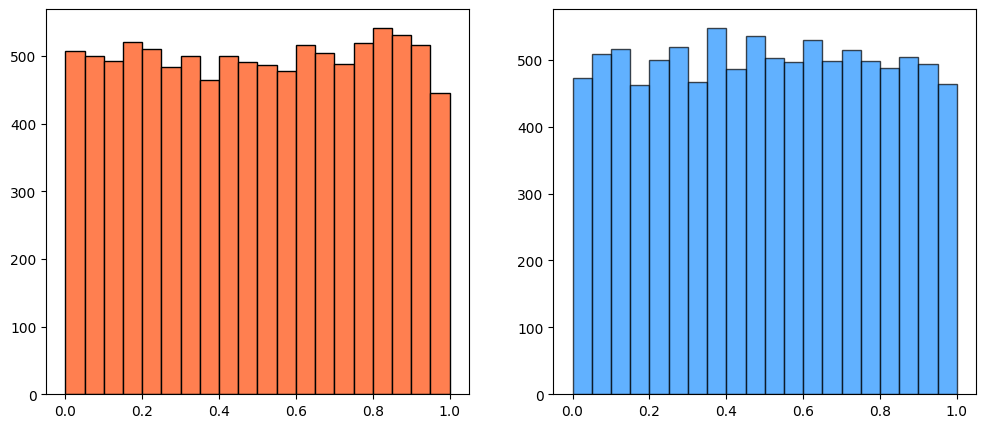

In [48]:
import random
import numpy as np
import matplotlib.pyplot as plt

list1 = [random.uniform(0,1) for _ in range(10000)]
list2 = np.random.rand(10000)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes[0].hist(list1, bins=20, color='coral', edgecolor='black') # bins : 구간의 갯수
axes[1].hist(list2, bins=20, color='dodgerblue', alpha=0.7, edgecolor='black')
plt.show()

물론입니다. 주어진 문제를 `f(x)` 함수를 직접 구현하는 데 초점을 맞춘 문제로 수정했습니다.

-----

## 실습 문제: 정규분포 확률 밀도 함수(PDF) 구현

**설명**: NumPy와 같은 라이브러리는 정규분포 샘플링을 위한 편리한 함수를 제공하지만, 그 근간이 되는 확률 밀도 함수(PDF, Probability Density Function)를 직접 구현해보는 것은 개념을 이해하는 데 큰 도움이 됩니다. 이 실습에서는 정규분포의 PDF 공식을 코드로 직접 작성하고, 이 함수의 그래프가 실제 데이터 샘플의 분포와 일치하는지 시각적으로 확인합니다.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\Bigl(-\frac{(x-\mu)^2}{2\sigma^2}\Bigr)$$

  - $\\mu$ : 평균 (mean)
  - $ \\sigma\\ $: 표준편차 (standard deviation)

**요구사항**:

  - 주어진 정규분포 PDF 공식을 파이썬 코드로 변환하여 `f(x, mu, sigma)` 함수를 완성하세요. `np.pi`와 `np.exp`를 활용하면 편리합니다.
  - 평균(`μ`) 0, 표준편차(`σ`) 1인 표준 정규분포의 PDF를 계산하도록 함수를 호출하세요.
  - `np.random.normal`로 생성한 샘플 데이터의 히스토그램과 직접 구현한 `f(x)` 함수의 그래프를 함께 그려, 두 결과가 일치하는지 확인합니다.

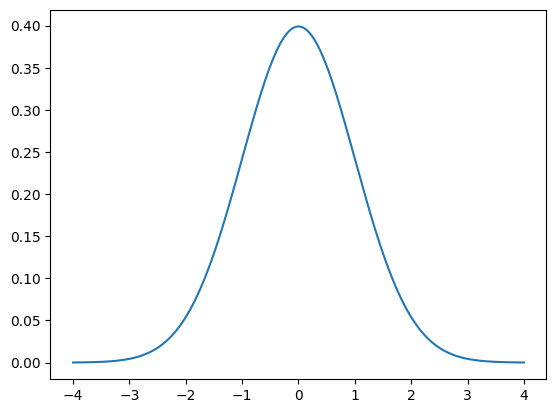

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, mu, sigma):
  """
  정규분포의 확률 밀도 함수(PDF)를 계산합니다.
  x: 확률 변수 값(들)
  mu: 평균
  sigma: 표준편차
  """
  result = 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2/(2*sigma**2)))
  # TODO: 정규분포 PDF 공식을 코드로 구현하세요.
  return result

mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
y = f(x, mu, sigma)

plt.plot(x,y)

In [57]:
np.random.normal(0,1,(100, 32,32)).shape

(100, 32, 32)

In [54]:
np.random.normal(170,10,10)

array([191.69629097, 169.1487196 , 171.78057103, 184.05470361,
       164.2312694 , 166.10457005, 166.10127788, 166.68439949,
       166.9433117 , 161.83034562])

(array([0.00044687, 0.00223435, 0.00789472, 0.0148957 , 0.03172783,
        0.04230377, 0.03232366, 0.01251238, 0.00283018, 0.00178748]),
 array([-29.92513772, -23.21178876, -16.49843981,  -9.78509085,
         -3.0717419 ,   3.64160706,  10.35495601,  17.06830496,
         23.78165392,  30.49500287,  37.20835183]),
 <BarContainer object of 10 artists>)

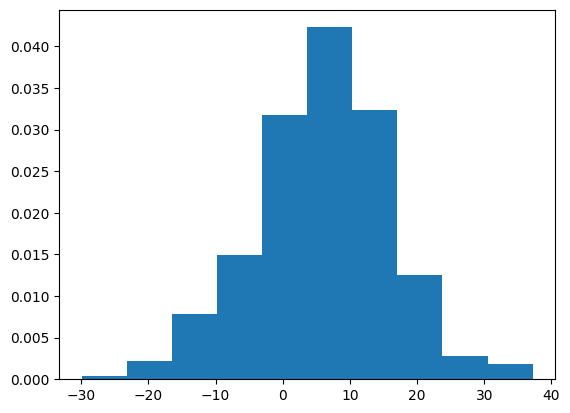

In [51]:
samples = np.random.normal(6, 10, 1000)
plt.hist(samples, density=True)

(array([0.02183337, 0.08577397, 0.21521468, 0.33529823, 0.40391741,
        0.28851243, 0.13879787, 0.05302391, 0.01559527, 0.00155953]),
 array([-2.72195322, -2.08073302, -1.43951283, -0.79829263, -0.15707243,
         0.48414777,  1.12536797,  1.76658816,  2.40780836,  3.04902856,
         3.69024876]),
 <BarContainer object of 10 artists>)

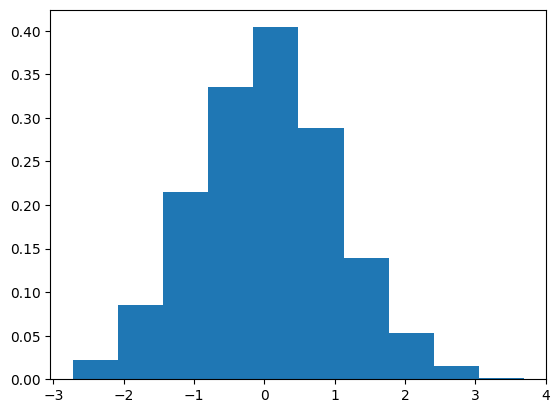

In [38]:
samples = np.random.normal(mu, sigma, 1000)
plt.hist(samples, density=True)

## 실습 문제: 정규 분포 난수 시각화

**설명**: NumPy의 `np.random.randn()` 함수는 머신러닝과 통계에서 매우 중요한 표준 정규 분포(평균 0, 표준편차 1)를 따르는 난수를 생성합니다. 이 실습에서는 이 함수를 사용하여 데이터를 생성하고, Matplotlib 히스토그램으로 시각화하여 정규 분포의 특징적인 '종 모양' 곡선을 직접 확인하는 것을 목표로 합니다.

$$f(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}x^2}$$

**요구사항**:
- `np.random.randn(1000)`을 호출하여 표준 정규 분포를 따르는 난수 1000개가 담긴 NumPy 배열을 생성하세요.
- Matplotlib을 사용하여 생성된 데이터의 히스토그램을 그리고, 그래프의 제목을 "Standard Normal Distribution"으로 설정하세요.
- 히스토그램이 데이터의 평균인 0을 중심으로 대칭적인 종 모양(bell shape)을 형성하는지 확인하고, 이전에 만들었던 균등 분포 히스토그램과 어떻게 다른지 생각해 보세요.

(array([  2.,   4.,  44., 101., 237., 306., 201.,  83.,  20.,   2.]),
 array([-4.06263747, -3.30857749, -2.55451751, -1.80045752, -1.04639754,
        -0.29233756,  0.46172243,  1.21578241,  1.96984239,  2.72390237,
         3.47796236]),
 <BarContainer object of 10 artists>)

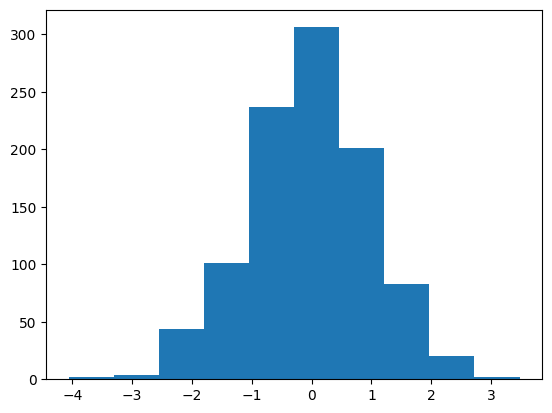

In [25]:
numpy = np.random.randn(1000)
plt.hist(numpy)

## 실습 문제: 3차 함수에 노이즈 추가 및 시각화

**설명**: 머신러닝 모델을 훈련할 때, 실제 데이터는 종종 이상적인 함수 관계에 무작위적인 노이즈가 더해진 형태로 나타납니다. 이 실습에서는 3차 함수 $f(x) = x^3 - x^2 + 3$ 라는 '참' 함수를 정의하고, 여기에 정규 분포 노이즈를 추가하여 실제 데이터와 유사한 형태를 만듭니다. 목표는 Matplotlib을 사용하여 원본 함수(선)와 노이즈가 포함된 데이터 포인트(산점도)를 함께 시각화하여 둘의 관계를 파악하는 것입니다.

$$y = x^3 - x^2 + 3$$

**요구사항**:
- `np.linspace`를 사용하여 -5부터 5까지의 범위에서 100개의 균일한 간격의 점으로 `x` 배열을 생성하세요.
- 생성된 `x` 값을 사용하여 3차 함수 $y = x^3 - x^2 + 3$를 계산하여 `y` 배열을 만드세요.
- `np.random.normal` 함수를 사용하여 평균 0, 표준편차 10인 정규 분포 노이즈를 100개 생성하고, 이를 `y` 배열에 더하여 노이즈가 추가된 데이터를 만드세요.
- Matplotlib을 사용하여 원본 $(x, y)$ 데이터는 선 그래프(`plt.plot`)로, 노이즈가 추가된 데이터는 산점도(`plt.scatter`)로 한 플롯에 함께 그리세요. 이를 통해 부드러운 원본 함수와 그 주변에 흩어진 데이터 포인트를 시각적으로 확인할 수 있습니다.

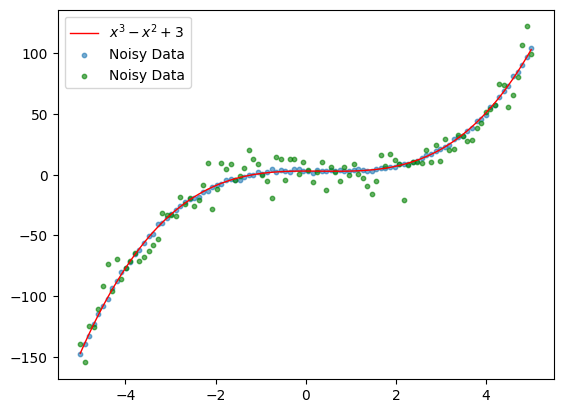

In [64]:
def f(x):
    return x**3-x**2+3
noise1 = np.random.normal(0,1,100)
noise2 = np.random.normal(0,10,100)
x = np.linspace(-5,5,100)
y = f(x)
y_noise1 = f(x)+noise1
y_noise2 = f(x)+noise2
plt.plot(x, y, color='red',label='$x^3 - x^2 + 3$', linewidth=1)
plt.scatter(x, y_noise1, label='Noisy Data', alpha=0.6, s=10)
plt.scatter(x, y_noise2, color = "green",label='Noisy Data', alpha=0.6, s=10)
plt.legend()